url of the data: https://www.kaggle.com/datasets/adisongoh/it-service-ticket-classification-dataset

In [ ]:


!unzip "/content/ticketit.zip" -d "/content"

Archive:  /content/ticketit.zip
  inflating: /content/all_tickets_processed_improved_v3.csv  


In [ ]:
import pandas as pd

In [ ]:
import numpy as np

In [ ]:
d=pd.read_csv("/content/all_tickets_processed_improved_v3.csv")

In [ ]:
d.head()

,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous


In [ ]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47837 entries, 0 to 47836
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Document     47837 non-null  object
 1   Topic_group  47837 non-null  object
dtypes: object(2)
memory usage: 747.6+ KB


In [ ]:
pd.set_option('display.max_colwidth', None)

In [ ]:
d.head(10)

,Document,Topic_group
0,connection with icon icon dear please setup icon per icon engineers please let other details needed thanks lead,Hardware
1,work experience user work experience user hi work experience student coming next his name much appreciate him duration thank,Access
2,requesting for meeting requesting meeting hi please help follow equipments cable pc cord plug,Hardware
3,reset passwords for external accounts re expire days hi ask help update passwords colleagues thank pm expire days importance high hi received about expiration please kindly help prolongation best regards pm expire days importance high dear expire days order change please follow steps prerequisites disable device credentials close active connected by cable machine note also follow steps detailed press ctrl alt delete same pops change item enter format enter enter newly chosen then re enter again submit displaying has changed os machine browse enter format enter gear icon top tight browser window enter enter newly chosen then re enter again save connected note complete resources granted once connected by cable browse tick want change after logging enter format enter log enter enter newly chosen then re enter again change clients suppliers about expire please touch person then communicate back encounter issues hesitate by accessing yours,Access
4,mail verification warning hi has got attached please addresses best regards monitoring analyst verification warning,Miscellaneous
5,mail please dear looks blacklisted receiving mails anymore sample attached thanks kind regards senior engineer,Miscellaneous
6,prod servers tunneling prod tunneling va la tunneling la host si la si host host cards port name bytes bytes seq bytes seq statistics packets transmitted received packet loss avg bytes bytes seq bytes seq tuesday pm acre re tunneling si pm acre re tunneling extended object host extended host extended object host range extended host range administrator re sector pm acre re tunneling va la si la tunneling design lead ext friday pm re tunneling va extended object host extended host administrator re sector pm tunneling va la tunneling users pinging bytes bytes bytes bytes bytes design lead ext con care pot partial strict si pot ale care va la contains proprietary information which legally privileged unauthorized dissemination prohibited intended recipient views addressing transmission error has misdirected please notify author by replying intended recipient must disclose distribute copy print rely,Hardware
7,access request dear modules report report cost thank much regards,HR Support
8,reset passwords for our client and passwords client dear please passwords thank,Access
9,direct reports missing time please action reports dear way help close these maternity leave complete submit her left he technically left he client work after rd submit after delete period days two public holidays possible add thanks please action reports dear part established processes each required submit his weekly basis each friday past must submitted receiving because reports haven followed process please help cascade accordingly gets possible breakdown reports please note refers has left maternity other absence leave please update person record otherwise please person directly submit country date total days,HR Support


In [ ]:
import re

def assign_priority(text):
    text = str(text).lower()

    if 'importance high' in text or 'urgent' in text or 'critical' in text:
        return 'High'

    if 'server' in text or 'crash' in text or 'down' in text or 'packet loss' in text:
        return 'High'

    if 'password' in text or 'access' in text or 'login' in text or 'icon' in text:
        return 'Low'

    return 'Medium'

d['Priority'] = d['Document'].apply(assign_priority)



In [ ]:
def clean_text(text):
    text = str(text).lower()
    #("hi", "thanks", "regards" etc)
    text = re.sub(r'\b(hi|hello|dear|thanks|regards|best|pm|am)\b', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    #Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

d['cleaned_text'] = d['Document'].apply(clean_text)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [ ]:
tfidf = TfidfVectorizer(max_features=5000) # Keep top 5000 words
X = tfidf.fit_transform(d['cleaned_text'])

y_category = d['Topic_group']
y_priority = d['Priority']

X_train, X_test, y_cat_train, y_cat_test, y_pri_train, y_pri_test = train_test_split(
    X, y_category, y_priority, test_size=0.2, random_state=42
)


In [ ]:
print("Training Category Model")
#class_weight=balanced
rf_category = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_category.fit(X_train, y_cat_train)
y_cat_pred = rf_category.predict(X_test)

print("Training Priority Model")
rf_priority = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_priority.fit(X_train, y_pri_train)
y_pri_pred = rf_priority.predict(X_test)

print("FINAL RESULTS: CATEGORY MODEL\n")
print(classification_report(y_cat_test, y_cat_pred))

print("FINAL RESULTS: PRIORITY MODEL\n")
print(classification_report(y_pri_test, y_pri_pred))

Training Category Model
Training Priority Model
FINAL RESULTS: CATEGORY MODEL

                       precision    recall  f1-score   support

               Access       0.91      0.86      0.89      1455
Administrative rights       0.88      0.66      0.75       342
           HR Support       0.84      0.85      0.85      2107
             Hardware       0.78      0.88      0.83      2760
     Internal Project       0.86      0.85      0.85       451
        Miscellaneous       0.83      0.77      0.80      1400
             Purchase       0.98      0.88      0.93       497
              Storage       0.92      0.83      0.87       556

             accuracy                           0.84      9568
            macro avg       0.87      0.82      0.84      9568
         weighted avg       0.85      0.84      0.84      9568

FINAL RESULTS: PRIORITY MODEL

              precision    recall  f1-score   support

        High       0.98      0.90      0.94      1327
         Low       0.9

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix



In [ ]:

def plot_confusion_matrix(y_true, y_pred, labels, title):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(12, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted Label')
    plt.ylabel('Actual Label')
    plt.title(title)
    plt.show()

category_labels = rf_category.classes_
priority_labels = rf_priority.classes_

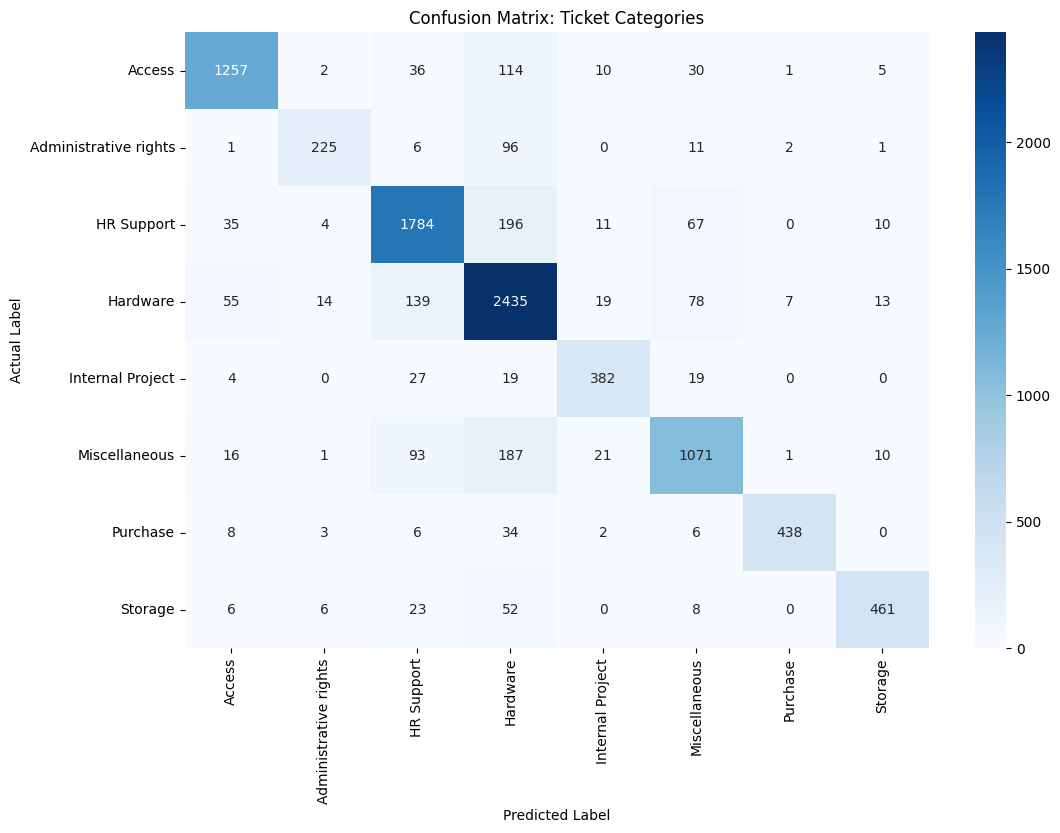

In [ ]:
plot_confusion_matrix(y_cat_test, y_cat_pred, category_labels, "Confusion Matrix: Ticket Categories")

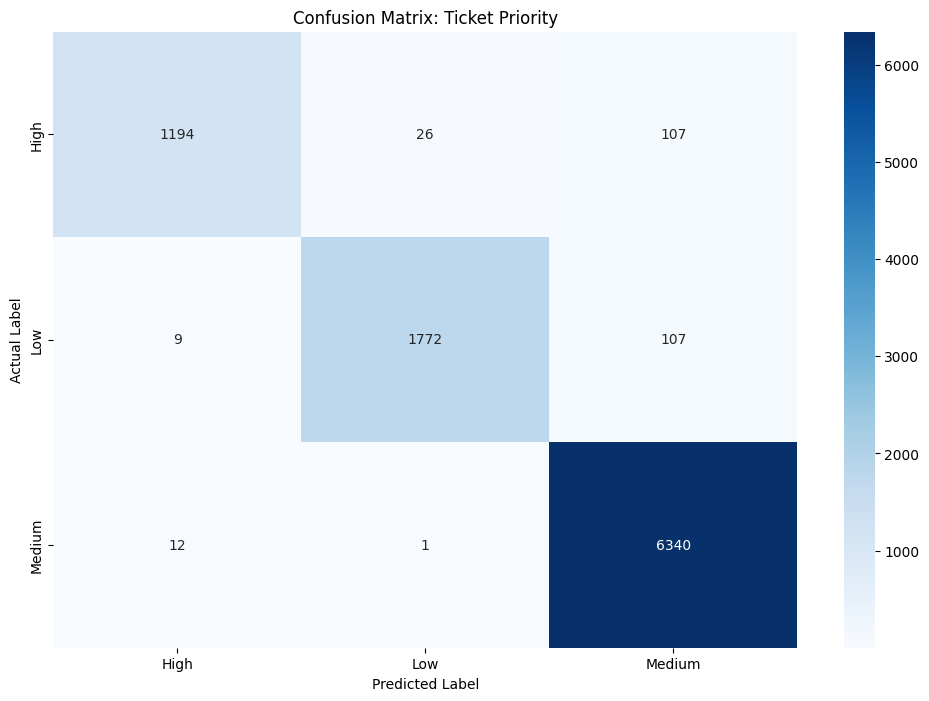

In [ ]:
plot_confusion_matrix(y_pri_test, y_pri_pred, priority_labels, "Confusion Matrix: Ticket Priority")

In [ ]:
def plot_top_words(model, feature_names, n_top=20, title="Top Words"):
    importances = model.feature_importances_
    indices = np.argsort(importances)[-n_top:]

    plt.figure(figsize=(10, 8))
    plt.title(title)
    plt.barh(range(len(indices)), importances[indices], color='b', align='center')
    plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
    plt.xlabel('Importance')
    plt.show()

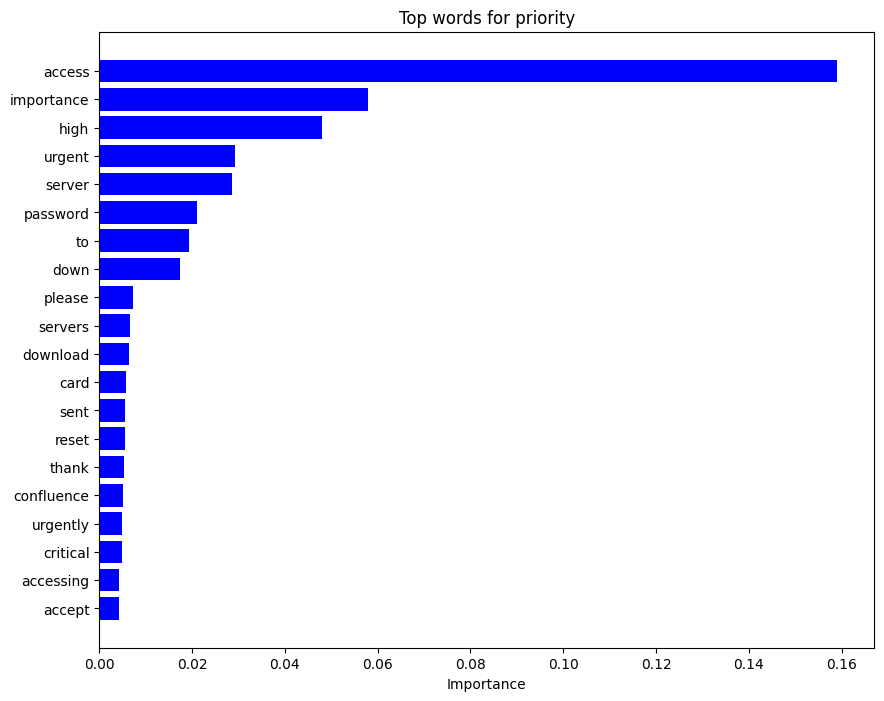

In [ ]:
feature_names = tfidf.get_feature_names_out()

plot_top_words(rf_priority, feature_names, title="Top words for priority")#20

In [ ]:

def predict_ticket(text):
    clean = clean_text(text)

    text_vectorized = tfidf.transform([clean])

    category_pred = rf_category.predict(text_vectorized)[0]
    priority_pred = rf_priority.predict(text_vectorized)[0]

    print(f"Ticket:   '{text}'")
    print(f"Category:  {category_pred}")
    print(f"Priority:  {priority_pred}")


predict_ticket("HELP! The main production server is down and no one can login. Fix immediately!")
predict_ticket("Hi, I need to purchase a new license for Adobe Photoshop. Who do I ask?")
predict_ticket("My laptop screen keeps flickering when I move the hinge.")


Ticket:   'HELP! The main production server is down and no one can login. Fix immediately!'
Category:  Hardware
Priority:  High
Ticket:   'Hi, I need to purchase a new license for Adobe Photoshop. Who do I ask?'
Category:  Access
Priority:  Medium
Ticket:   'My laptop screen keeps flickering when I move the hinge.'
Category:  Hardware
Priority:  Medium


In [ ]:
inp=input("Enter ticket:")
predict_ticket(inp)

Enter ticket:My password isnt working.
Ticket:   'My password isnt working.'
Category:  Access
Priority:  Low


In [ ]:
'''import joblib

print("Saving models")
joblib.dump(rf_category, 'ticket_category_model.joblib')
joblib.dump(rf_priority, 'ticket_priority_model.joblib')
joblib.dump(tfidf, 'tfidf_vectorizer.joblib')

print("Saved")'''

'import joblib\n\nprint("Saving models")\njoblib.dump(rf_category, \'ticket_category_model.joblib\')\njoblib.dump(rf_priority, \'ticket_priority_model.joblib\')\njoblib.dump(tfidf, \'tfidf_vectorizer.joblib\') \n\nprint("Saved")'